In [5]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

In [7]:
file_path = '/content/drive/MyDrive/marketing_campaign_dataset.csv'

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (200000, 16)


In [8]:
import os

for root, dirs, files in os.walk('/content/drive/MyDrive'):
    for file in files:
        if file.endswith('.csv'):
            print(os.path.join(root, file))

/content/drive/MyDrive/caesar_data.csv
/content/drive/MyDrive/caesar_test.csv
/content/drive/MyDrive/urban_planning_dataset.csv
/content/drive/MyDrive/Sample - Superstore.csv
/content/drive/MyDrive/sample_submission.csv
/content/drive/MyDrive/Student_performance.csv
/content/drive/MyDrive/marketing_campaign_dataset.csv
/content/drive/MyDrive/model_results.csv
/content/drive/MyDrive/results.csv


In [9]:
df.head()

,Campaign_ID,Company,Campaign_Type,Target_Audience,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Language,Clicks,Impressions,Engagement_Score,Customer_Segment,Date
0,1,Innovate Industries,Email,Men 18-24,30 days,Google Ads,0.04,"$16,174.00",6.29,Chicago,Spanish,506,1922,6,Health & Wellness,2021-01-01
1,2,NexGen Systems,Email,Women 35-44,60 days,Google Ads,0.12,"$11,566.00",5.61,New York,German,116,7523,7,Fashionistas,2021-01-02
2,3,Alpha Innovations,Influencer,Men 25-34,30 days,YouTube,0.07,"$10,200.00",7.18,Los Angeles,French,584,7698,1,Outdoor Adventurers,2021-01-03
3,4,DataTech Solutions,Display,All Ages,60 days,YouTube,0.11,"$12,724.00",5.55,Miami,Mandarin,217,1820,7,Health & Wellness,2021-01-04
4,5,NexGen Systems,Email,Men 25-34,15 days,YouTube,0.05,"$16,452.00",6.50,Los Angeles,Mandarin,379,4201,3,Health & Wellness,2021-01-05


In [10]:
df.tail()

,Campaign_ID,Company,Campaign_Type,Target_Audience,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Language,Clicks,Impressions,Engagement_Score,Customer_Segment,Date
199995,199996,TechCorp,Display,All Ages,30 days,Google Ads,0.06,"$18,365.00",2.84,Chicago,German,858,5988,1,Tech Enthusiasts,2021-12-07
199996,199997,DataTech Solutions,Email,Men 25-34,15 days,Facebook,0.02,"$8,168.00",4.14,Chicago,Spanish,228,3068,7,Foodies,2021-12-08
199997,199998,DataTech Solutions,Social Media,Men 18-24,45 days,Website,0.05,"$13,397.00",3.25,New York,Mandarin,723,9548,3,Tech Enthusiasts,2021-12-09
199998,199999,Innovate Industries,Influencer,All Ages,30 days,YouTube,0.10,"$18,508.00",3.86,Houston,French,528,2763,1,Foodies,2021-12-10
199999,200000,Innovate Industries,Social Media,Women 35-44,45 days,Google Ads,0.01,"$13,835.00",6.64,Chicago,Spanish,924,7287,8,Tech Enthusiasts,2021-12-11


In [11]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 200000
Number of columns: 16


In [12]:
print("Columns in dataset:")

for i, column in enumerate(df.columns, start=1):
    print(i, ":", column)

Columns in dataset:
1 : Campaign_ID
2 : Company
3 : Campaign_Type
4 : Target_Audience
5 : Duration
6 : Channel_Used
7 : Conversion_Rate
8 : Acquisition_Cost
9 : ROI
10 : Location
11 : Language
12 : Clicks
13 : Impressions
14 : Engagement_Score
15 : Customer_Segment
16 : Date


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Campaign_ID       200000 non-null  int64  
 1   Company           200000 non-null  object 
 2   Campaign_Type     200000 non-null  object 
 3   Target_Audience   200000 non-null  object 
 4   Duration          200000 non-null  object 
 5   Channel_Used      200000 non-null  object 
 6   Conversion_Rate   200000 non-null  float64
 7   Acquisition_Cost  200000 non-null  object 
 8   ROI               200000 non-null  float64
 9   Location          200000 non-null  object 
 10  Language          200000 non-null  object 
 11  Clicks            200000 non-null  int64  
 12  Impressions       200000 non-null  int64  
 13  Engagement_Score  200000 non-null  int64  
 14  Customer_Segment  200000 non-null  object 
 15  Date              200000 non-null  object 
dtypes: float64(2), int64

In [14]:
df.describe()

,Campaign_ID,Conversion_Rate,ROI,Clicks,Impressions,Engagement_Score
count,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000
mean,100000.500000,0.080070,5.002438,549.772030,5507.301520,5.494710
std,57735.171256,0.040602,1.734488,260.019056,2596.864286,2.872581
min,1.000000,0.010000,2.000000,100.000000,1000.000000,1.000000
25%,50000.750000,0.050000,3.500000,325.000000,3266.000000,3.000000
50%,100000.500000,0.080000,5.010000,550.000000,5517.500000,5.000000
75%,150000.250000,0.120000,6.510000,775.000000,7753.000000,8.000000
max,200000.000000,0.150000,8.000000,1000.000000,10000.000000,10.000000


In [15]:
df.describe(include='object')

,Company,Campaign_Type,Target_Audience,Duration,Channel_Used,Acquisition_Cost,Location,Language,Customer_Segment,Date
count,200000,200000,200000,200000,200000,200000,200000,200000,200000,200000
unique,5,5,5,4,6,15001,5,5,5,365
top,TechCorp,Influencer,Men 18-24,30 days,Email,"$16,578.00",Miami,Mandarin,Foodies,2021-12-02
freq,40237,40169,40258,50255,33599,32,40269,40255,40208,548


In [16]:
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
Campaign_ID         0
Company             0
Campaign_Type       0
Target_Audience     0
Duration            0
Channel_Used        0
Conversion_Rate     0
Acquisition_Cost    0
ROI                 0
Location            0
Language            0
Clicks              0
Impressions         0
Engagement_Score    0
Customer_Segment    0
Date                0
dtype: int64


In [17]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_table = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Percentage': missing_percentage
})

missing_table

,Missing Values,Percentage
Campaign_ID,0,0.0
Company,0,0.0
Campaign_Type,0,0.0
Target_Audience,0,0.0
Duration,0,0.0
Channel_Used,0,0.0
Conversion_Rate,0,0.0
Acquisition_Cost,0,0.0
ROI,0,0.0
Location,0,0.0


In [18]:
duplicates = df.duplicated().sum()

print("Number of duplicate rows:", duplicates)

Number of duplicate rows: 0


In [19]:
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (200000, 16)


In [20]:
df.dtypes

,0
Campaign_ID,int64
Company,object
Campaign_Type,object
Target_Audience,object
Duration,object
Channel_Used,object
Conversion_Rate,float64
Acquisition_Cost,object
ROI,float64
Location,object


In [21]:
df['Duration_Days'] = (
    df['Duration']
    .str.replace(' days', '', regex=False)
    .astype(int)
)

df[['Duration', 'Duration_Days']].head()

,Duration,Duration_Days
0,30 days,30
1,60 days,60
2,30 days,30
3,60 days,60
4,15 days,15


In [22]:
df['Acquisition_Cost_Clean'] = (
    df['Acquisition_Cost']
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
    .astype(float)
)

df[['Acquisition_Cost', 'Acquisition_Cost_Clean']].head()

,Acquisition_Cost,Acquisition_Cost_Clean
0,"$16,174.00",16174.0
1,"$11,566.00",11566.0
2,"$10,200.00",10200.0
3,"$12,724.00",12724.0
4,"$16,452.00",16452.0


In [23]:
df['Date'] = pd.to_datetime(df['Date'])

print(df['Date'].dtype)

datetime64[ns]


In [24]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Month_Name'] = df['Date'].dt.month_name()
df['Day'] = df['Date'].dt.day
df['Day_of_Week'] = df['Date'].dt.day_name()
df['Quarter'] = df['Date'].dt.quarter

df[['Date', 'Year', 'Month', 'Month_Name',
    'Day_of_Week', 'Quarter']].head()

,Date,Year,Month,Month_Name,Day_of_Week,Quarter
0,2021-01-01,2021,1,January,Friday,1
1,2021-01-02,2021,1,January,Saturday,1
2,2021-01-03,2021,1,January,Sunday,1
3,2021-01-04,2021,1,January,Monday,1
4,2021-01-05,2021,1,January,Tuesday,1


In [25]:
df['CTR'] = (df['Clicks'] / df['Impressions']) * 100

df[['Clicks', 'Impressions', 'CTR']].head()

,Clicks,Impressions,CTR
0,506,1922,26.326743
1,116,7523,1.541938
2,584,7698,7.586386
3,217,1820,11.923077
4,379,4201,9.021662


In [26]:
df['Estimated_Conversions'] = (
    df['Clicks'] * df['Conversion_Rate']
)

df[['Clicks', 'Conversion_Rate',
    'Estimated_Conversions']].head()

,Clicks,Conversion_Rate,Estimated_Conversions
0,506,0.04,20.24
1,116,0.12,13.92
2,584,0.07,40.88
3,217,0.11,23.87
4,379,0.05,18.95


In [27]:
df['Cost_Per_Click'] = (
    df['Acquisition_Cost_Clean'] / df['Clicks']
)

df[['Acquisition_Cost_Clean', 'Clicks',
    'Cost_Per_Click']].head()

,Acquisition_Cost_Clean,Clicks,Cost_Per_Click
0,16174.0,506,31.964427
1,11566.0,116,99.706897
2,10200.0,584,17.465753
3,12724.0,217,58.635945
4,16452.0,379,43.408971


In [28]:
df['Cost_Per_Conversion'] = (
    df['Acquisition_Cost_Clean'] /
    df['Estimated_Conversions']
)

df[['Acquisition_Cost_Clean',
    'Estimated_Conversions',
    'Cost_Per_Conversion']].head()

,Acquisition_Cost_Clean,Estimated_Conversions,Cost_Per_Conversion
0,16174.0,20.24,799.110672
1,11566.0,13.92,830.890805
2,10200.0,40.88,249.510763
3,12724.0,23.87,533.054043
4,16452.0,18.95,868.179420


In [29]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()

Rows: 200000
Columns: 28


,Campaign_ID,Company,Campaign_Type,Target_Audience,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Language,Clicks,Impressions,Engagement_Score,Customer_Segment,Date,Duration_Days,Acquisition_Cost_Clean,Year,Month,Month_Name,Day,Day_of_Week,Quarter,CTR,Estimated_Conversions,Cost_Per_Click,Cost_Per_Conversion
0,1,Innovate Industries,Email,Men 18-24,30 days,Google Ads,0.04,"$16,174.00",6.29,Chicago,Spanish,506,1922,6,Health & Wellness,2021-01-01,30,16174.0,2021,1,January,1,Friday,1,26.326743,20.24,31.964427,799.110672
1,2,NexGen Systems,Email,Women 35-44,60 days,Google Ads,0.12,"$11,566.00",5.61,New York,German,116,7523,7,Fashionistas,2021-01-02,60,11566.0,2021,1,January,2,Saturday,1,1.541938,13.92,99.706897,830.890805
2,3,Alpha Innovations,Influencer,Men 25-34,30 days,YouTube,0.07,"$10,200.00",7.18,Los Angeles,French,584,7698,1,Outdoor Adventurers,2021-01-03,30,10200.0,2021,1,January,3,Sunday,1,7.586386,40.88,17.465753,249.510763
3,4,DataTech Solutions,Display,All Ages,60 days,YouTube,0.11,"$12,724.00",5.55,Miami,Mandarin,217,1820,7,Health & Wellness,2021-01-04,60,12724.0,2021,1,January,4,Monday,1,11.923077,23.87,58.635945,533.054043
4,5,NexGen Systems,Email,Men 25-34,15 days,YouTube,0.05,"$16,452.00",6.50,Los Angeles,Mandarin,379,4201,3,Health & Wellness,2021-01-05,15,16452.0,2021,1,January,5,Tuesday,1,9.021662,18.95,43.408971,868.179420


In [30]:
total_cost = df['Acquisition_Cost_Clean'].sum()
average_roi = df['ROI'].mean()
average_conversion = df['Conversion_Rate'].mean()
total_clicks = df['Clicks'].sum()
total_impressions = df['Impressions'].sum()
average_ctr = df['CTR'].mean()
average_engagement = df['Engagement_Score'].mean()

print(f"Total Acquisition Cost: ${total_cost:,.2f}")
print(f"Average ROI: {average_roi:.4f}")
print(f"Average Conversion Rate: {average_conversion:.4f}")
print(f"Total Clicks: {total_clicks:,}")
print(f"Total Impressions: {total_impressions:,}")
print(f"Average CTR: {average_ctr:.2f}%")
print(f"Average Engagement Score: {average_engagement:.2f}")

Total Acquisition Cost: $2,500,878,608.00
Average ROI: 5.0024
Average Conversion Rate: 0.0801
Total Clicks: 109,954,406
Total Impressions: 1,101,460,304
Average CTR: 14.04%
Average Engagement Score: 5.49


In [31]:
categorical_columns = [
    'Company',
    'Campaign_Type',
    'Target_Audience',
    'Channel_Used',
    'Location',
    'Language',
    'Customer_Segment'
]

for column in categorical_columns:
    print("\n", column)
    print(df[column].value_counts())


 Company
Company
TechCorp               40237
Alpha Innovations      40051
DataTech Solutions     40012
NexGen Systems         39991
Innovate Industries    39709
Name: count, dtype: int64

 Campaign_Type
Campaign_Type
Influencer      40169
Search          40157
Display         39987
Email           39870
Social Media    39817
Name: count, dtype: int64

 Target_Audience
Target_Audience
Men 18-24      40258
Men 25-34      40023
All Ages       40019
Women 25-34    40013
Women 35-44    39687
Name: count, dtype: int64

 Channel_Used
Channel_Used
Email         33599
Google Ads    33438
YouTube       33392
Instagram     33392
Website       33360
Facebook      32819
Name: count, dtype: int64

 Location
Location
Miami          40269
New York       40024
Chicago        40010
Los Angeles    39947
Houston        39750
Name: count, dtype: int64

 Language
Language
Mandarin    40255
Spanish     40102
German      39983
English     39896
French      39764
Name: count, dtype: int64

 Customer_Segment


In [32]:
campaign_type_counts = df['Campaign_Type'].value_counts()

print(campaign_type_counts)

Campaign_Type
Influencer      40169
Search          40157
Display         39987
Email           39870
Social Media    39817
Name: count, dtype: int64


In [34]:
roi_by_campaign = (
    df.groupby('Campaign_Type')['ROI']
    .mean()
    .sort_values(ascending=False)
)

print(roi_by_campaign)

Campaign_Type
Influencer      5.011068
Search          5.008357
Display         5.006551
Email           4.994295
Social Media    4.991784
Name: ROI, dtype: float64


In [36]:
conversion_by_campaign = (
    df.groupby('Campaign_Type')['Conversion_Rate']
    .mean()
    .sort_values(ascending=False)
)

print(conversion_by_campaign)

Campaign_Type
Influencer      0.080315
Social Media    0.080135
Display         0.080089
Search          0.080021
Email           0.079788
Name: Conversion_Rate, dtype: float64


In [38]:
cost_by_campaign = (
    df.groupby('Campaign_Type')['Acquisition_Cost_Clean']
    .mean()
    .sort_values(ascending=False)
)

print(cost_by_campaign)

Campaign_Type
Social Media    12512.698094
Display         12508.034461
Influencer      12507.170330
Search          12498.736459
Email           12495.346100
Name: Acquisition_Cost_Clean, dtype: float64


In [39]:
channel_analysis = (
    df.groupby('Channel_Used')
    .agg(
        Campaigns=('Campaign_ID', 'count'),
        Average_ROI=('ROI', 'mean'),
        Average_Conversion=('Conversion_Rate', 'mean'),
        Average_CTR=('CTR', 'mean'),
        Average_Engagement=('Engagement_Score', 'mean'),
        Average_Cost=('Acquisition_Cost_Clean', 'mean'),
        Total_Clicks=('Clicks', 'sum'),
        Total_Impressions=('Impressions', 'sum')
    )
    .sort_values('Average_ROI', ascending=False)
)

channel_analysis

,Campaigns,Average_ROI,Average_Conversion,Average_CTR,Average_Engagement,Average_Cost,Total_Clicks,Total_Impressions
Channel_Used,,,,,,,,
Facebook,32819,5.018699,0.079992,14.049926,5.503702,12510.900942,18037947,180659428
Website,33360,5.014167,0.080183,14.097136,5.508903,12487.814748,18414628,183806353
Google Ads,33438,5.003141,0.080183,13.918967,5.494049,12528.031401,18340807,185006879
Email,33599,4.996487,0.080282,14.054269,5.487842,12526.387809,18493963,184801107
YouTube,33392,4.993754,0.079889,14.119605,5.484937,12481.390213,18350407,183448082
Instagram,33392,4.988706,0.079886,14.003691,5.489039,12491.760002,18316654,183738455


In [42]:
channel_engagement = (
    df.groupby('Channel_Used')['Engagement_Score']
    .mean()
    .sort_values(ascending=False)
)

print(channel_engagement)

Channel_Used
Website       5.508903
Facebook      5.503702
Google Ads    5.494049
Instagram     5.489039
Email         5.487842
YouTube       5.484937
Name: Engagement_Score, dtype: float64


In [44]:
segment_analysis = (
    df.groupby('Customer_Segment')
    .agg(
        Campaigns=('Campaign_ID', 'count'),
        Average_ROI=('ROI', 'mean'),
        Average_Conversion=('Conversion_Rate', 'mean'),
        Average_Engagement=('Engagement_Score', 'mean'),
        Average_CTR=('CTR', 'mean'),
        Average_Cost=('Acquisition_Cost_Clean', 'mean')
    )
    .sort_values('Average_ROI', ascending=False)
)

segment_analysis

,Campaigns,Average_ROI,Average_Conversion,Average_Engagement,Average_CTR,Average_Cost
Customer_Segment,,,,,,
Foodies,40208,5.004376,0.080257,5.511465,14.141301,12524.558148
Tech Enthusiasts,40151,5.004234,0.080168,5.485168,14.112726,12480.392991
Health & Wellness,39888,5.003202,0.079945,5.484156,13.985696,12504.418346
Fashionistas,39742,5.000962,0.079794,5.489910,13.995284,12503.445574
Outdoor Adventurers,40011,4.999393,0.080180,5.502737,13.966519,12509.128540


In [46]:
audience_analysis = (
    df.groupby('Target_Audience')
    .agg(
        Campaigns=('Campaign_ID', 'count'),
        Average_ROI=('ROI', 'mean'),
        Average_Conversion=('Conversion_Rate', 'mean'),
        Average_CTR=('CTR', 'mean'),
        Average_Engagement=('Engagement_Score', 'mean')
    )
    .sort_values('Average_ROI', ascending=False)
)

audience_analysis

,Campaigns,Average_ROI,Average_Conversion,Average_CTR,Average_Engagement
Target_Audience,,,,,
Men 25-34,40023,5.020627,0.080132,14.013420,5.491942
Women 35-44,39687,5.006330,0.080102,14.057890,5.486507
All Ages,40019,5.005174,0.079975,13.980181,5.487094
Women 25-34,40013,4.997351,0.079899,14.103079,5.492740
Men 18-24,40258,4.982853,0.080240,14.048287,5.515078


In [47]:
location_analysis = (
    df.groupby('Location')
    .agg(
        Campaigns=('Campaign_ID', 'count'),
        Average_ROI=('ROI', 'mean'),
        Average_Conversion=('Conversion_Rate', 'mean'),
        Average_Engagement=('Engagement_Score', 'mean'),
        Average_CTR=('CTR', 'mean')
    )
    .sort_values('Average_ROI', ascending=False)
)

location_analysis

,Campaigns,Average_ROI,Average_Conversion,Average_Engagement,Average_CTR
Location,,,,,
Miami,40269,5.012282,0.080047,5.495766,14.024957
Los Angeles,39947,5.010876,0.080013,5.488823,14.067175
Houston,39750,5.007203,0.079948,5.514692,14.058906
Chicago,40010,5.001590,0.080134,5.505074,14.045204
New York,40024,4.980228,0.080204,5.469318,14.006780


In [49]:
language_analysis = (
    df.groupby('Language')
    .agg(
        Campaigns=('Campaign_ID', 'count'),
        Average_ROI=('ROI', 'mean'),
        Average_Conversion=('Conversion_Rate', 'mean'),
        Average_Engagement=('Engagement_Score', 'mean')
    )
    .sort_values('Average_ROI', ascending=False)
)

language_analysis

,Campaigns,Average_ROI,Average_Conversion,Average_Engagement
Language,,,,
French,39764,5.011375,0.080254,5.468212
Mandarin,40255,5.007313,0.080036,5.505577
Spanish,40102,5.001705,0.079918,5.496210
German,39983,5.001054,0.079973,5.505690
English,39896,4.990734,0.080169,5.497644


In [50]:
monthly_analysis = (
    df.groupby(['Year', 'Month'])
    .agg(
        Campaigns=('Campaign_ID', 'count'),
        Average_ROI=('ROI', 'mean'),
        Average_Conversion=('Conversion_Rate', 'mean'),
        Average_CTR=('CTR', 'mean'),
        Average_Engagement=('Engagement_Score', 'mean'),
        Total_Cost=('Acquisition_Cost_Clean', 'sum')
    )
    .reset_index()
)

monthly_analysis.head()

,Year,Month,Campaigns,Average_ROI,Average_Conversion,Average_CTR,Average_Engagement,Total_Cost
0,2021,1,16988,5.014595,0.080084,14.152063,5.455321,212138826.0
1,2021,2,15344,5.005248,0.080181,14.081157,5.503650,191464820.0
2,2021,3,16988,4.983404,0.080032,14.020457,5.520426,211892603.0
3,2021,4,16440,4.994372,0.080460,13.983970,5.467214,205452322.0
4,2021,5,16988,5.018923,0.079781,14.153381,5.529962,211663415.0


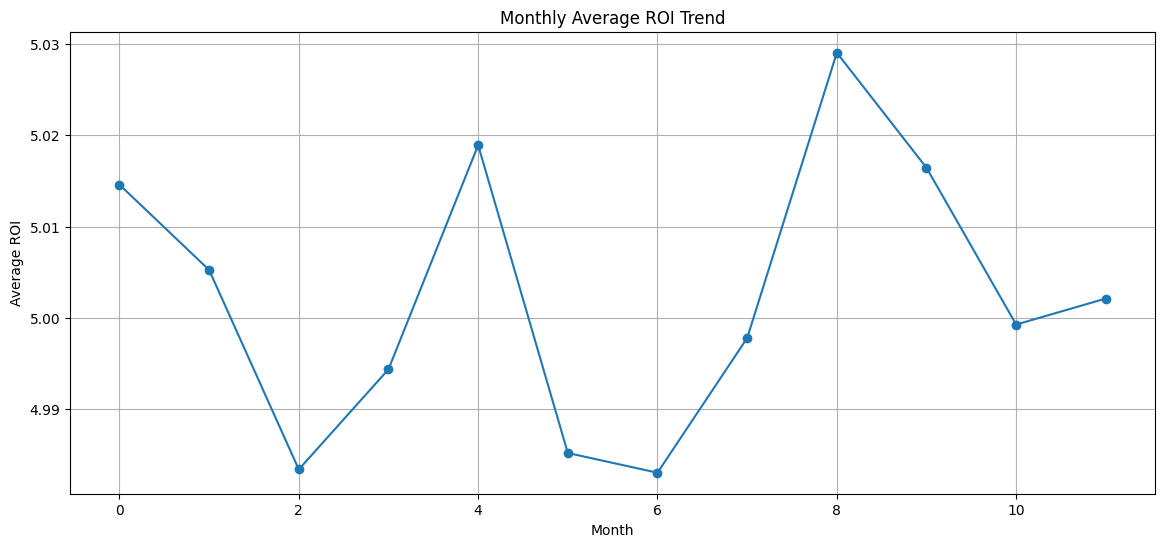

In [51]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_analysis.index,
    monthly_analysis['Average_ROI'],
    marker='o'
)

plt.title('Monthly Average ROI Trend')
plt.xlabel('Month')
plt.ylabel('Average ROI')
plt.grid(True)

plt.show()

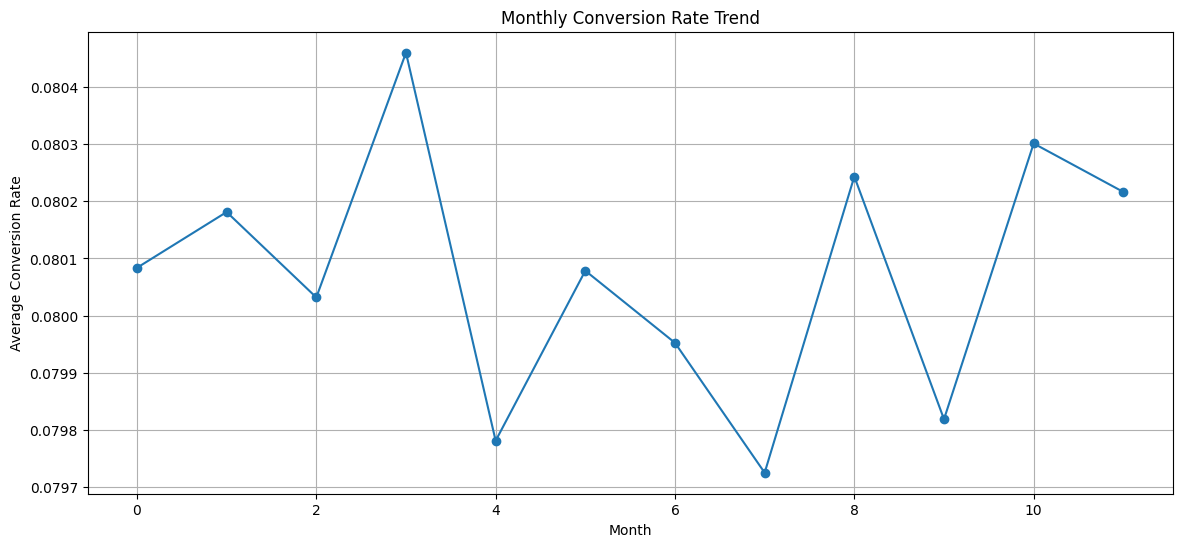

In [52]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_analysis.index,
    monthly_analysis['Average_Conversion'],
    marker='o'
)

plt.title('Monthly Conversion Rate Trend')
plt.xlabel('Month')
plt.ylabel('Average Conversion Rate')
plt.grid(True)

plt.show()

In [53]:
numeric_columns = [
    'Conversion_Rate',
    'Acquisition_Cost_Clean',
    'ROI',
    'Clicks',
    'Impressions',
    'Engagement_Score',
    'Duration_Days',
    'CTR',
    'Estimated_Conversions',
    'Cost_Per_Click',
    'Cost_Per_Conversion'
]

correlation_matrix = df[numeric_columns].corr()

correlation_matrix

,Conversion_Rate,Acquisition_Cost_Clean,ROI,Clicks,Impressions,Engagement_Score,Duration_Days,CTR,Estimated_Conversions,Cost_Per_Click,Cost_Per_Conversion
Conversion_Rate,1.000000,0.000718,-0.001143,0.000269,-0.002834,-0.000638,-0.001058,-0.000049,0.690841,0.002525,-0.478866
Acquisition_Cost_Clean,0.000718,1.000000,0.004585,0.000141,0.000329,-0.003218,0.000941,-0.000899,-0.000260,0.409993,0.226901
ROI,-0.001143,0.004585,1.000000,-0.002040,0.002257,0.000588,0.001154,-0.002116,-0.001528,0.004575,0.003389
Clicks,0.000269,0.000141,-0.002040,1.000000,0.000033,-0.001908,-0.001455,0.506526,0.644981,-0.727437,-0.400734
Impressions,-0.002834,0.000329,0.002257,0.000033,1.000000,0.003030,-0.006323,-0.657538,-0.000951,-0.000027,0.004340
Engagement_Score,-0.000638,-0.003218,0.000588,-0.001908,0.003030,1.000000,-0.003009,-0.005747,-0.001165,0.000976,0.000448
Duration_Days,-0.001058,0.000941,0.001154,-0.001455,-0.006323,-0.003009,1.000000,0.003222,-0.000092,0.002509,0.005620
CTR,-0.000049,-0.000899,-0.002116,0.506526,-0.657538,-0.005747,0.003222,1.000000,0.326682,-0.368952,-0.203906
Estimated_Conversions,0.690841,-0.000260,-0.001528,0.644981,-0.000951,-0.001165,-0.000092,0.326682,1.000000,-0.468597,-0.493260
Cost_Per_Click,0.002525,0.409993,0.004575,-0.727437,-0.000027,0.000976,0.002509,-0.368952,-0.468597,1.000000,0.550478


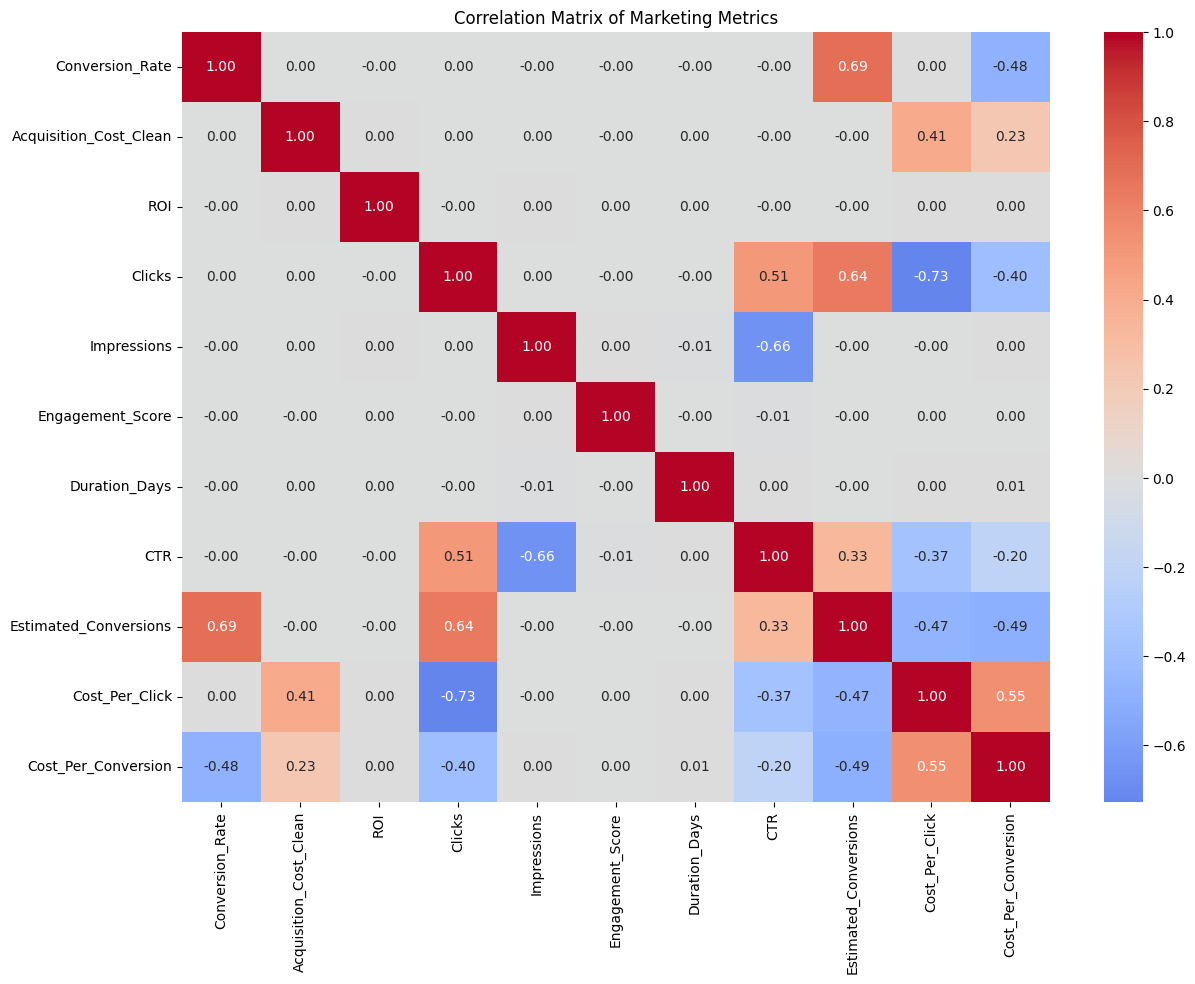

In [54]:
plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Matrix of Marketing Metrics')

plt.show()

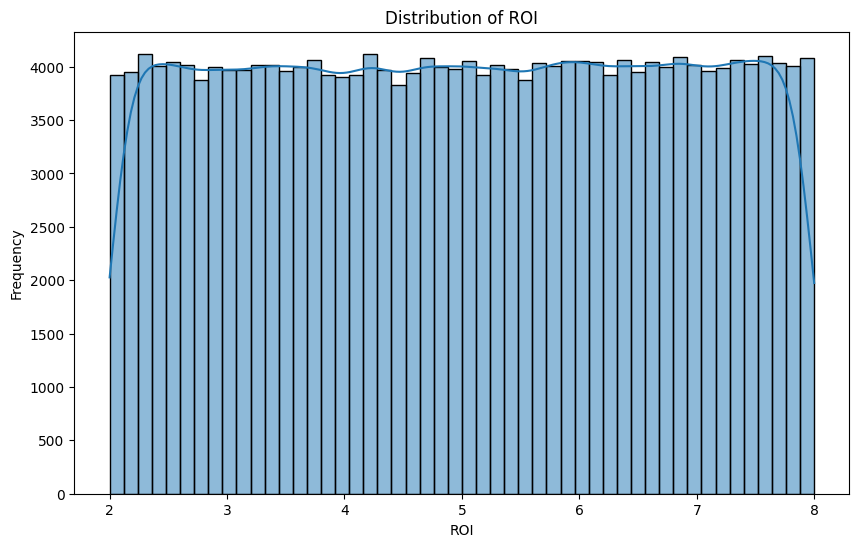

In [55]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df['ROI'],
    bins=50,
    kde=True
)

plt.title('Distribution of ROI')
plt.xlabel('ROI')
plt.ylabel('Frequency')

plt.show()

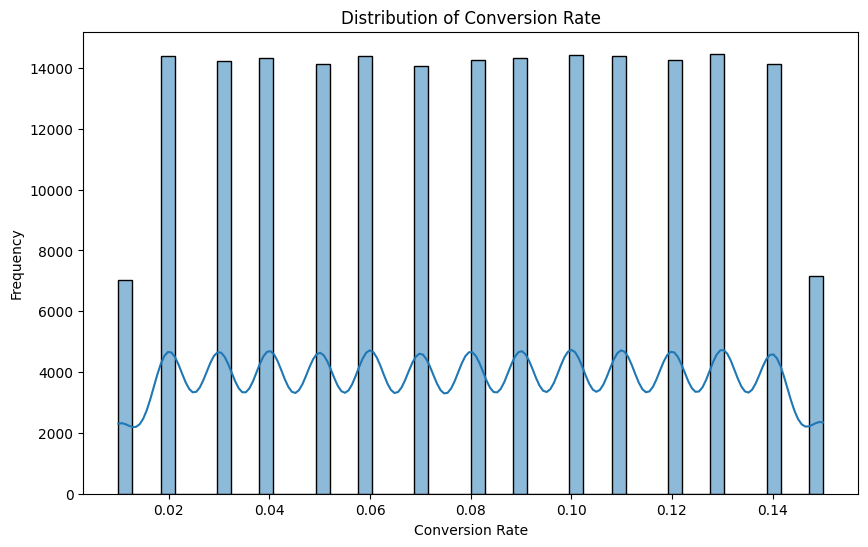

In [56]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df['Conversion_Rate'],
    bins=50,
    kde=True
)

plt.title('Distribution of Conversion Rate')
plt.xlabel('Conversion Rate')
plt.ylabel('Frequency')

plt.show()

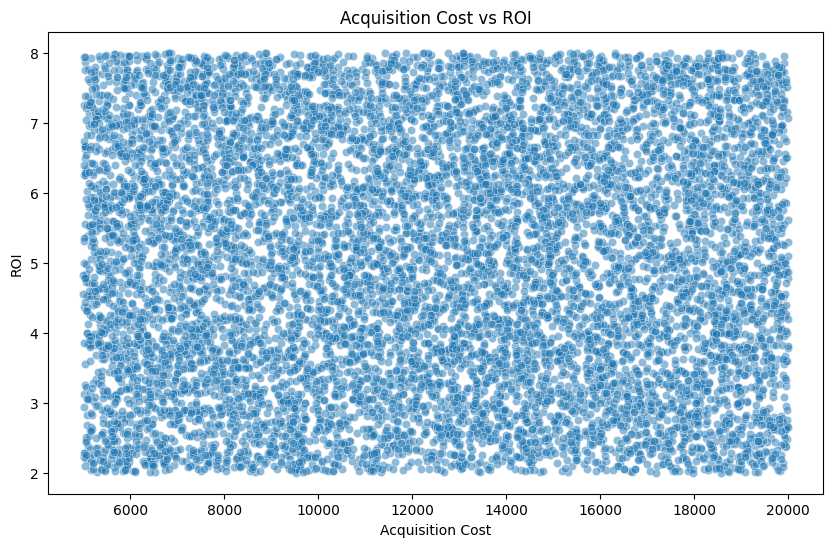

In [59]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df.sample(10000),
    x='Acquisition_Cost_Clean',
    y='ROI',
    alpha=0.5
)

plt.title('Acquisition Cost vs ROI')
plt.xlabel('Acquisition Cost')
plt.ylabel('ROI')

plt.show()

In [60]:
top_roi_campaigns = (
    df.sort_values('ROI', ascending=False)
    .head(20)
)

top_roi_campaigns[
    [
        'Campaign_ID',
        'Company',
        'Campaign_Type',
        'Channel_Used',
        'ROI',
        'Conversion_Rate',
        'CTR',
        'Engagement_Score'
    ]
]

,Campaign_ID,Company,Campaign_Type,Channel_Used,ROI,Conversion_Rate,CTR,Engagement_Score
65640,65641,Alpha Innovations,Search,Website,8.0,0.09,1.614060,9
143790,143791,Alpha Innovations,Influencer,Website,8.0,0.06,7.973605,3
143503,143504,Innovate Industries,Influencer,YouTube,8.0,0.04,14.801525,5
121639,121640,TechCorp,Influencer,Google Ads,8.0,0.14,20.808561,7
120917,120918,TechCorp,Social Media,Website,8.0,0.11,16.811280,9
73364,73365,Innovate Industries,Display,Website,8.0,0.15,8.149920,5
48870,48871,TechCorp,Display,Website,8.0,0.12,7.692308,10
42868,42869,DataTech Solutions,Display,Website,8.0,0.01,20.178372,8
42999,43000,NexGen Systems,Email,Google Ads,8.0,0.09,11.779041,4
83445,83446,Alpha Innovations,Search,Email,8.0,0.04,8.500172,2


In [61]:
lowest_roi_campaigns = (
    df.sort_values('ROI', ascending=True)
    .head(20)
)

lowest_roi_campaigns[
    [
        'Campaign_ID',
        'Company',
        'Campaign_Type',
        'Channel_Used',
        'ROI',
        'Conversion_Rate',
        'CTR',
        'Engagement_Score'
    ]
]

,Campaign_ID,Company,Campaign_Type,Channel_Used,ROI,Conversion_Rate,CTR,Engagement_Score
158656,158657,TechCorp,Email,Email,2.0,0.07,1.540436,10
19662,19663,TechCorp,Social Media,Instagram,2.0,0.11,9.239130,6
104137,104138,NexGen Systems,Influencer,Instagram,2.0,0.14,15.367077,3
57347,57348,TechCorp,Search,Email,2.0,0.12,7.152260,5
41738,41739,TechCorp,Search,Google Ads,2.0,0.13,36.232630,2
100277,100278,DataTech Solutions,Social Media,YouTube,2.0,0.04,4.676649,7
100262,100263,DataTech Solutions,Display,Email,2.0,0.02,6.440815,7
93777,93778,TechCorp,Influencer,YouTube,2.0,0.13,7.232887,9
144205,144206,Alpha Innovations,Influencer,Website,2.0,0.14,24.211921,2
59881,59882,Alpha Innovations,Influencer,Facebook,2.0,0.07,1.770458,4


In [62]:
company_analysis = (
    df.groupby('Company')
    .agg(
        Campaigns=('Campaign_ID', 'count'),
        Average_ROI=('ROI', 'mean'),
        Average_Conversion=('Conversion_Rate', 'mean'),
        Average_Engagement=('Engagement_Score', 'mean'),
        Total_Cost=('Acquisition_Cost_Clean', 'sum')
    )
    .sort_values('Average_ROI', ascending=False)
)

company_analysis.head(20)

,Campaigns,Average_ROI,Average_Conversion,Average_Engagement,Total_Cost
Company,,,,,
TechCorp,40237,5.007143,0.080157,5.475284,503335248.0
Alpha Innovations,40051,5.005944,0.080084,5.497041,501182021.0
DataTech Solutions,40012,5.005537,0.079989,5.501425,500281064.0
Innovate Industries,39709,5.002175,0.080384,5.507920,496383769.0
NexGen Systems,39991,4.991353,0.079736,5.492086,499696506.0


In [63]:
channel_campaign_analysis = (
    df.groupby(['Channel_Used', 'Campaign_Type'])
    .agg(
        Campaigns=('Campaign_ID', 'count'),
        Average_ROI=('ROI', 'mean'),
        Average_Conversion=('Conversion_Rate', 'mean'),
        Average_CTR=('CTR', 'mean'),
        Average_Engagement=('Engagement_Score', 'mean')
    )
    .sort_values('Average_ROI', ascending=False)
)

channel_campaign_analysis.head(20)

Campaigns  Average_ROI  Average_Conversion  \
Channel_Used Campaign_Type                                               
Facebook     Search              6488     5.033110            0.080268   
Website      Search              6899     5.031826            0.079919   
Email        Display             6701     5.030919            0.080075   
Website      Display             6622     5.030686            0.080445   
Facebook     Influencer          6548     5.026686            0.080154   
Website      Influencer          6650     5.025426            0.080230   
YouTube      Influencer          6773     5.024395            0.080058   
Facebook     Social Media        6566     5.021544            0.079758   
             Email               6589     5.011501            0.079859   
Google Ads   Email               6689     5.011126            0.080111   
Instagram    Search              6623     5.007164            0.079763   
Google Ads   Search              6720     5.005131            0.080604   
             Display             6590     5.003464            0.079977   
YouTube      Display             6722     5.003317            0.080153   
Email        Email               6760     5.002873            0.079538   
Google Ads   Influencer          6764     5.002175            0.080334   
Facebook     Display             6628     5.001037            0.079925   
YouTube      Search              6709     4.999608            0.079629   
Instagram    Influencer          6736     4.997622            0.079868   
Google Ads   Social Media        6675     4.993798            0.079883   

                            Average_CTR  Average_Engagement  
Channel_Used Campaign_Type                                   
Facebook     Search           13.971475            5.516184  
Website      Search           14.101192            5.494130  
Email        Display          14.210915            5.532906  
Website      Display          14.121174            5.533223  
Facebook     Influencer       14.162924            5.513439  
Website      Influencer       14.124674            5.481955  
YouTube      Influencer       13.952920            5.509228  
Facebook     Social Media     14.142632            5.512336  
             Email            13.919770            5.450448  
Google Ads   Email            13.903980            5.496337  
Instagram    Search           13.911548            5.475615  
Google Ads   Search           14.013756            5.488393  
             Display          14.009284            5.517147  
YouTube      Display          14.375909            5.459982  
Email        Email            13.995401            5.520710  
Google Ads   Influencer       13.958593            5.455648  
Facebook     Display          14.052637            5.526252  
YouTube      Search           14.042400            5.466985  
Instagram    Influencer       14.023983            5.483967  
Google Ads   Social Media     13.709238            5.513558

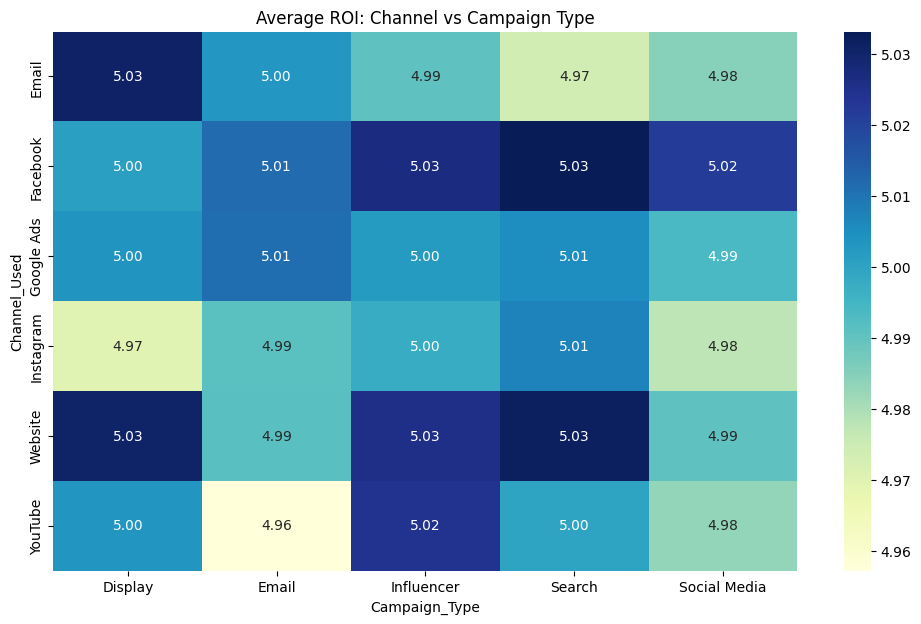

In [64]:
pivot_roi = df.pivot_table(
    values='ROI',
    index='Channel_Used',
    columns='Campaign_Type',
    aggfunc='mean'
)

plt.figure(figsize=(12, 7))

sns.heatmap(
    pivot_roi,
    annot=True,
    fmt='.2f',
    cmap='YlGnBu'
)

plt.title('Average ROI: Channel vs Campaign Type')

plt.show()

In [65]:
segment_channel_roi = df.pivot_table(
    values='ROI',
    index='Customer_Segment',
    columns='Channel_Used',
    aggfunc='mean'
)

segment_channel_roi

Channel_Used,Email,Facebook,Google Ads,Instagram,Website,YouTube
Customer_Segment,,,,,,
Fashionistas,4.987897,5.004506,5.029717,5.010496,5.020863,4.952345
Foodies,4.991678,5.009666,4.969647,4.998445,5.033461,5.024107
Health & Wellness,5.021867,5.006555,5.019812,4.968776,5.014928,4.987938
Outdoor Adventurers,4.970791,5.022944,5.004235,4.993492,5.009121,4.996338
Tech Enthusiasts,5.010684,5.049569,4.992330,4.972552,4.992975,5.007916


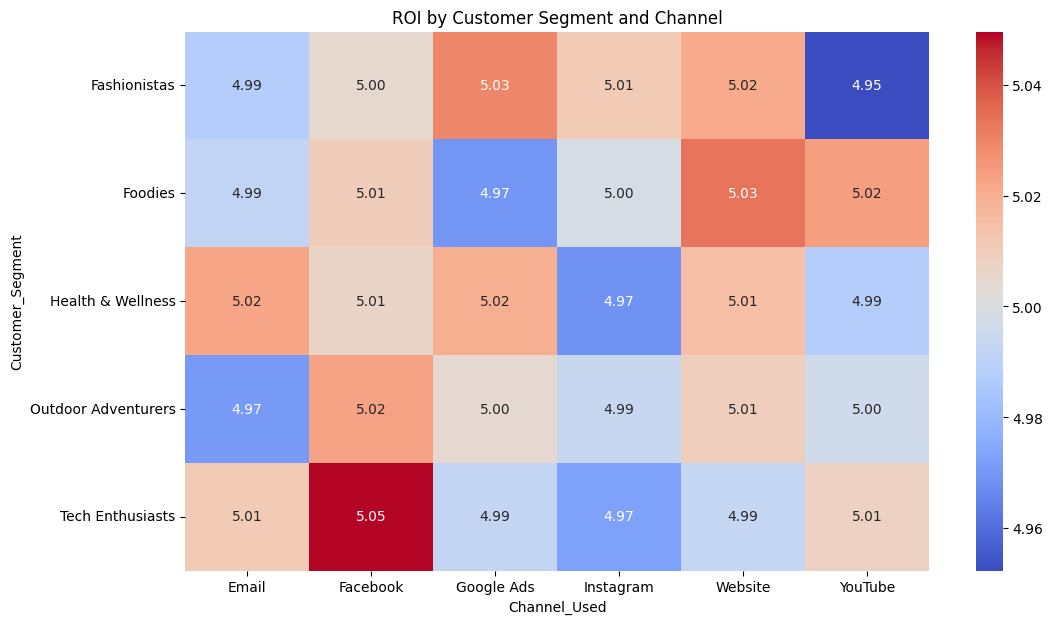

In [66]:
plt.figure(figsize=(12, 7))

sns.heatmap(
    segment_channel_roi,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title('ROI by Customer Segment and Channel')

plt.show()

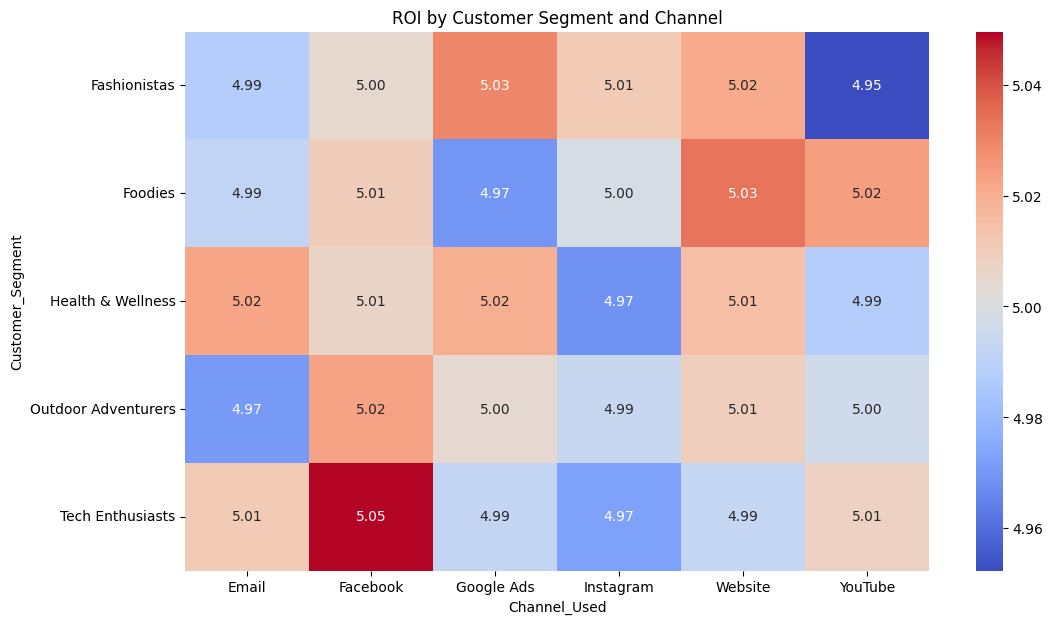

In [67]:
plt.figure(figsize=(12, 7))

sns.heatmap(
    segment_channel_roi,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title('ROI by Customer Segment and Channel')

plt.show()

In [68]:
ml_df = df.copy()

ml_df = ml_df.drop(
    columns=[
        'Campaign_ID',
        'Date',
        'Month_Name',
        'Day_of_Week',
        'Duration',
        'Acquisition_Cost'
    ]
)

print(ml_df.shape)
ml_df.head()

(200000, 22)


,Company,Campaign_Type,Target_Audience,Channel_Used,Conversion_Rate,ROI,Location,Language,Clicks,Impressions,Engagement_Score,Customer_Segment,Duration_Days,Acquisition_Cost_Clean,Year,Month,Day,Quarter,CTR,Estimated_Conversions,Cost_Per_Click,Cost_Per_Conversion
0,Innovate Industries,Email,Men 18-24,Google Ads,0.04,6.29,Chicago,Spanish,506,1922,6,Health & Wellness,30,16174.0,2021,1,1,1,26.326743,20.24,31.964427,799.110672
1,NexGen Systems,Email,Women 35-44,Google Ads,0.12,5.61,New York,German,116,7523,7,Fashionistas,60,11566.0,2021,1,2,1,1.541938,13.92,99.706897,830.890805
2,Alpha Innovations,Influencer,Men 25-34,YouTube,0.07,7.18,Los Angeles,French,584,7698,1,Outdoor Adventurers,30,10200.0,2021,1,3,1,7.586386,40.88,17.465753,249.510763
3,DataTech Solutions,Display,All Ages,YouTube,0.11,5.55,Miami,Mandarin,217,1820,7,Health & Wellness,60,12724.0,2021,1,4,1,11.923077,23.87,58.635945,533.054043
4,NexGen Systems,Email,Men 25-34,YouTube,0.05,6.50,Los Angeles,Mandarin,379,4201,3,Health & Wellness,15,16452.0,2021,1,5,1,9.021662,18.95,43.408971,868.179420


In [69]:
X = ml_df.drop(columns=['ROI'])
y = ml_df['ROI']

print("Features:", X.shape)
print("Target:", y.shape)

Features: (200000, 21)
Target: (200000,)


In [70]:
categorical_features = X.select_dtypes(
    include=['object']
).columns.tolist()

numerical_features = X.select_dtypes(
    exclude=['object']
).columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Categorical features:
['Company', 'Campaign_Type', 'Target_Audience', 'Channel_Used', 'Location', 'Language', 'Customer_Segment']

Numerical features:
['Conversion_Rate', 'Clicks', 'Impressions', 'Engagement_Score', 'Duration_Days', 'Acquisition_Cost_Clean', 'Year', 'Month', 'Day', 'Quarter', 'CTR', 'Estimated_Conversions', 'Cost_Per_Click', 'Cost_Per_Conversion']


In [71]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 160000
Testing rows: 40000


In [72]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            'categorical',
            OneHotEncoder(handle_unknown='ignore'),
            categorical_features
        ),
        (
            'numerical',
            'passthrough',
            numerical_features
        )
    ]
)

In [73]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    max_depth=15
)

In [74]:
pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ]
)

In [75]:
print("Training model...")

pipeline.fit(X_train, y_train)

print("Model training completed!")

Training model...
Model training completed!


In [76]:
y_pred = pipeline.predict(X_test)

print("Predictions generated successfully!")

Predictions generated successfully!


In [77]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

MAE  : 1.5035
MSE  : 3.0165
RMSE : 1.7368
R²   : -0.0016


In [78]:
comparison = pd.DataFrame({
    'Actual_ROI': y_test.values,
    'Predicted_ROI': y_pred
})

comparison.head(20)

,Actual_ROI,Predicted_ROI
0,6.34,5.001667
1,2.75,5.020930
2,3.72,4.995473
3,5.45,4.979474
4,6.72,5.158113
5,6.40,5.037226
6,4.73,4.984451
7,7.70,4.971599
8,2.44,5.004629
9,4.23,4.974612


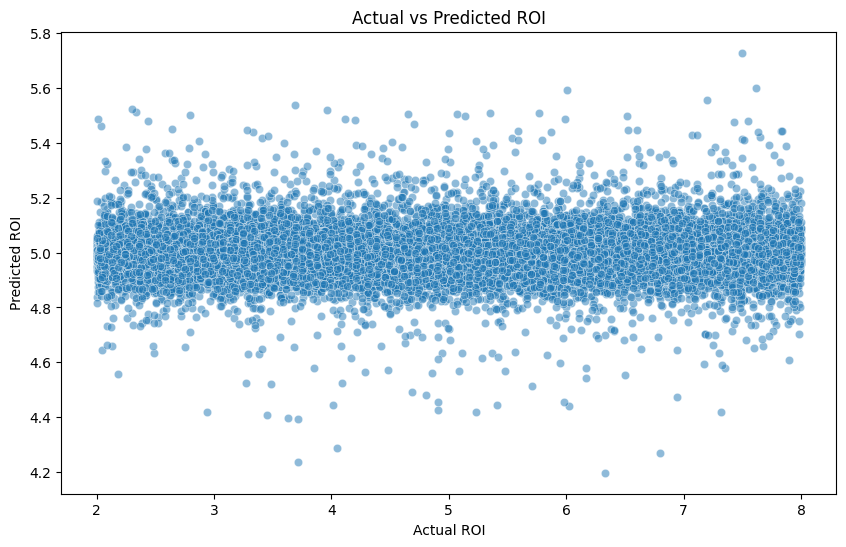

In [79]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    x=y_test,
    y=y_pred,
    alpha=0.5
)

plt.xlabel('Actual ROI')
plt.ylabel('Predicted ROI')
plt.title('Actual vs Predicted ROI')

plt.show()

In [80]:
comparison['Error'] = (
    comparison['Actual_ROI'] -
    comparison['Predicted_ROI']
)

comparison['Absolute_Error'] = (
    comparison['Error'].abs()
)

comparison.head()

,Actual_ROI,Predicted_ROI,Error,Absolute_Error
0,6.34,5.001667,1.338333,1.338333
1,2.75,5.020930,-2.270930,2.270930
2,3.72,4.995473,-1.275473,1.275473
3,5.45,4.979474,0.470526,0.470526
4,6.72,5.158113,1.561887,1.561887


In [81]:
feature_names = (
    pipeline
    .named_steps['preprocessor']
    .get_feature_names_out()
)

importances = (
    pipeline
    .named_steps['model']
    .feature_importances_
)

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

feature_importance = feature_importance.sort_values(
    'Importance',
    ascending=False
)

feature_importance.head(20)

,Feature,Importance
41,numerical__Acquisition_Cost_Clean,0.095952
38,numerical__Impressions,0.093687
46,numerical__CTR,0.086696
48,numerical__Cost_Per_Click,0.079667
49,numerical__Cost_Per_Conversion,0.075987
47,numerical__Estimated_Conversions,0.070878
44,numerical__Day,0.063754
37,numerical__Clicks,0.061641
39,numerical__Engagement_Score,0.041064
43,numerical__Month,0.036975


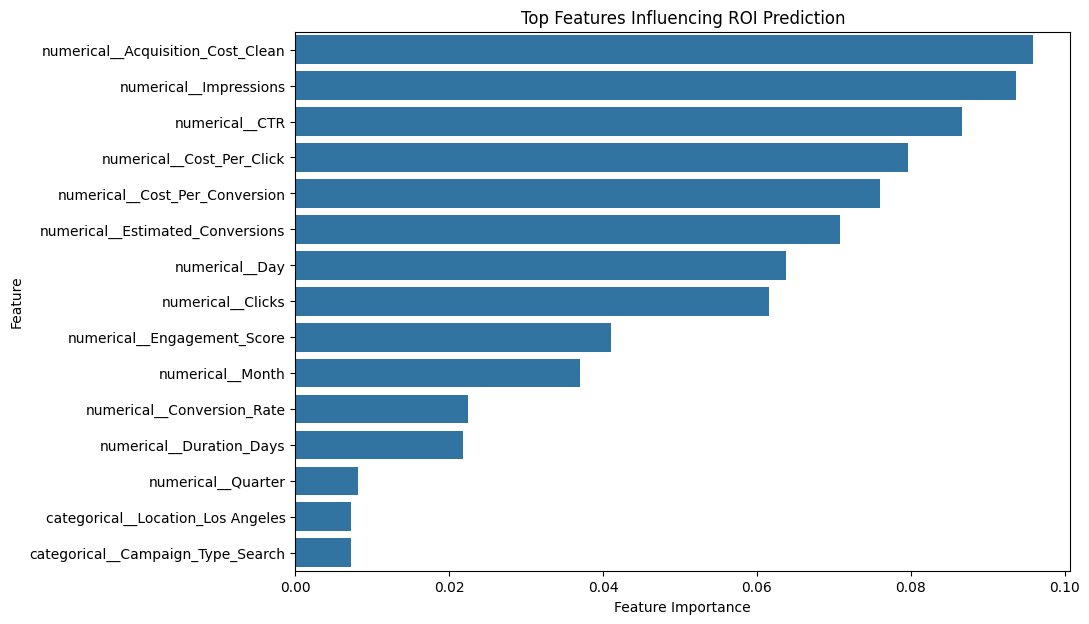

In [82]:
top_features = feature_importance.head(15)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_features,
    x='Importance',
    y='Feature'
)

plt.title('Top Features Influencing ROI Prediction')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')

plt.show()

In [83]:
final_kpis = pd.DataFrame({
    'Metric': [
        'Total Campaigns',
        'Total Acquisition Cost',
        'Average ROI',
        'Average Conversion Rate',
        'Average CTR',
        'Average Engagement Score',
        'Total Clicks',
        'Total Impressions'
    ],
    'Value': [
        len(df),
        total_cost,
        average_roi,
        average_conversion,
        average_ctr,
        average_engagement,
        total_clicks,
        total_impressions
    ]
})

final_kpis

,Metric,Value
0,Total Campaigns,2.000000e+05
1,Total Acquisition Cost,2.500879e+09
2,Average ROI,5.002438e+00
3,Average Conversion Rate,8.006965e-02
4,Average CTR,1.404055e+01
5,Average Engagement Score,5.494710e+00
6,Total Clicks,1.099544e+08
7,Total Impressions,1.101460e+09


In [84]:
best_campaign_type = (
    df.groupby('Campaign_Type')['ROI']
    .mean()
    .idxmax()
)

best_channel = (
    df.groupby('Channel_Used')['ROI']
    .mean()
    .idxmax()
)

best_segment = (
    df.groupby('Customer_Segment')['ROI']
    .mean()
    .idxmax()
)

best_location = (
    df.groupby('Location')['ROI']
    .mean()
    .idxmax()
)

best_language = (
    df.groupby('Language')['ROI']
    .mean()
    .idxmax()
)

print("Best Campaign Type:", best_campaign_type)
print("Best Channel:", best_channel)
print("Best Customer Segment:", best_segment)
print("Best Location:", best_location)
print("Best Language:", best_language)

Best Campaign Type: Influencer
Best Channel: Facebook
Best Customer Segment: Foodies
Best Location: Miami
Best Language: French


In [85]:
worst_campaign_type = (
    df.groupby('Campaign_Type')['ROI']
    .mean()
    .idxmin()
)

worst_channel = (
    df.groupby('Channel_Used')['ROI']
    .mean()
    .idxmin()
)

worst_segment = (
    df.groupby('Customer_Segment')['ROI']
    .mean()
    .idxmin()
)

print("Lowest ROI Campaign Type:", worst_campaign_type)
print("Lowest ROI Channel:", worst_channel)
print("Lowest ROI Customer Segment:", worst_segment)

Lowest ROI Campaign Type: Social Media
Lowest ROI Channel: Instagram
Lowest ROI Customer Segment: Outdoor Adventurers


In [86]:
print("=" * 60)
print("MARKETING CAMPAIGN DATA ANALYSIS SUMMARY")
print("=" * 60)

print(f"\nTotal Campaigns       : {len(df):,}")
print(f"Total Acquisition Cost: ${total_cost:,.2f}")
print(f"Average ROI           : {average_roi:.4f}")
print(f"Average Conversion    : {average_conversion:.4f}")
print(f"Average CTR           : {average_ctr:.2f}%")
print(f"Average Engagement    : {average_engagement:.2f}")

print("\nBEST PERFORMERS")
print("-" * 30)

print(f"Campaign Type : {best_campaign_type}")
print(f"Channel       : {best_channel}")
print(f"Segment       : {best_segment}")
print(f"Location      : {best_location}")
print(f"Language      : {best_language}")

print("\nLOWEST PERFORMERS")
print("-" * 30)

print(f"Campaign Type : {worst_campaign_type}")
print(f"Channel       : {worst_channel}")
print(f"Segment       : {worst_segment}")

print("=" * 60)

MARKETING CAMPAIGN DATA ANALYSIS SUMMARY

Total Campaigns       : 200,000
Total Acquisition Cost: $2,500,878,608.00
Average ROI           : 5.0024
Average Conversion    : 0.0801
Average CTR           : 14.04%
Average Engagement    : 5.49

BEST PERFORMERS
------------------------------
Campaign Type : Influencer
Channel       : Facebook
Segment       : Foodies
Location      : Miami
Language      : French

LOWEST PERFORMERS
------------------------------
Campaign Type : Social Media
Channel       : Instagram
Segment       : Outdoor Adventurers


In [87]:
output_path = '/content/drive/MyDrive/data/cleaned_marketing_campaign_data.csv'

df.to_csv(
    output_path,
    index=False
)

print("Cleaned dataset saved to:")
print(output_path)

Cleaned dataset saved to:
/content/drive/MyDrive/data/cleaned_marketing_campaign_data.csv


In [88]:
analysis_path = '/content/drive/MyDrive/data/marketing_analysis.xlsx'

with pd.ExcelWriter(analysis_path) as writer:

    final_kpis.to_excel(
        writer,
        sheet_name='KPI Summary',
        index=False
    )

    channel_analysis.to_excel(
        writer,
        sheet_name='Channel Analysis'
    )

    segment_analysis.to_excel(
        writer,
        sheet_name='Segment Analysis'
    )

    location_analysis.to_excel(
        writer,
        sheet_name='Location Analysis'
    )

    language_analysis.to_excel(
        writer,
        sheet_name='Language Analysis'
    )

    company_analysis.to_excel(
        writer,
        sheet_name='Company Analysis'
    )

    channel_campaign_analysis.to_excel(
        writer,
        sheet_name='Channel Campaign'
    )

    feature_importance.to_excel(
        writer,
        sheet_name='Feature Importance',
        index=False
    )

print("Excel analysis report saved!")

Excel analysis report saved!


In [89]:
top_campaigns_path = '/content/drive/MyDrive/data/top_marketing_campaigns.csv'

top_roi_campaigns.to_csv(
    top_campaigns_path,
    index=False
)

print("Top campaigns saved!")

Top campaigns saved!
